In [32]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

#coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_for_training.csv")

# Create the target column
coffee_data['target'] = coffee_data['caffeine_class'].map(lambda x: 0 if x == 'Absent' else 1)

# Store the column names before scaling
column_names = coffee_data.drop(columns=['caffeine_class', 'caffeine_percent', 'target']).columns

scaler = StandardScaler()
X_scaled_std = scaler.fit_transform(coffee_data.drop(columns=['caffeine_class', 'caffeine_percent', 'target']))
X = X_scaled_std.copy()  # Your scaled data
y = coffee_data['target']

In [5]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

def evaluate_model(model, X, y, cv=5):
    # Define the scoring metrics
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'roc_auc': make_scorer(roc_auc_score),
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1': make_scorer(f1_score)
    }

    # Perform cross-validation
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring)

    # Compute the mean of each metric across all folds
    results = {
        'accuracy': cv_results['test_accuracy'].mean(),
        'roc_auc': cv_results['test_roc_auc'].mean(),
        'precision': cv_results['test_precision'].mean(),
        'recall': cv_results['test_recall'].mean(),
        'f1': cv_results['test_f1'].mean()
    }

    return results


In [6]:
# Assuming X and y are your input data and target, and model is your machine learning model

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Call the function to evaluate the model
results = evaluate_model(rf_model, X_train, y_train, cv=5)

# Print the results
print("Cross-validation results (mean values):")
for metric, value in results.items():
    print(f"{metric.capitalize()}: {value:.4f}")

Cross-validation results (mean values):
Accuracy: 0.9348
Roc_auc: 0.9087
Precision: 0.9200
Recall: 0.8514
F1: 0.8810


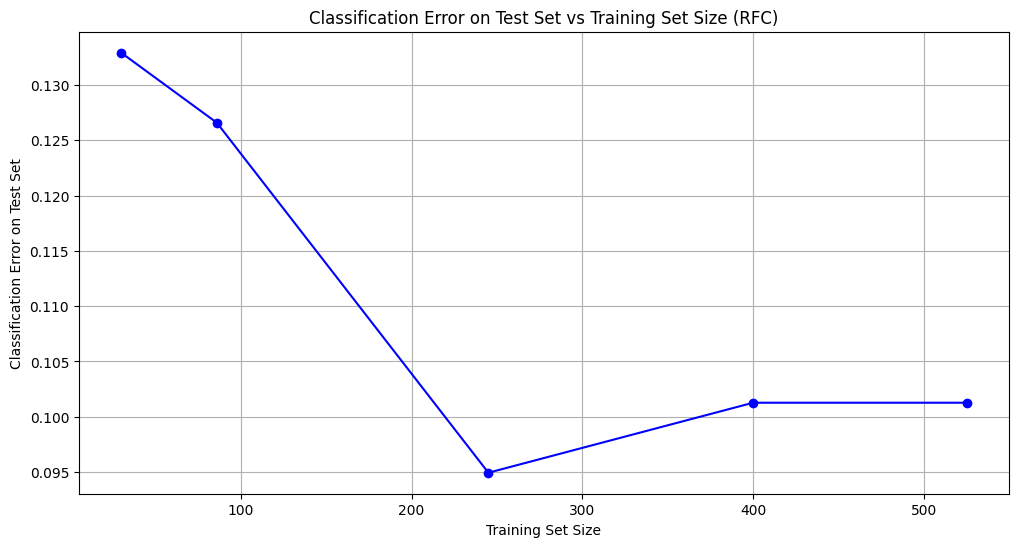

In [7]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# Splitting data into different training sizes and a common test set
train_sizes = [30, 86, 245, 400, 525]
test_fold_results = []
# Using a common test set size of 30% of the data
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

for train_size in train_sizes:
    # Subsetting the training data to the desired size
    X_train = X_train_full[:train_size]
    y_train = y_train_full[:train_size]

    # Initializing and training the model
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

    # Calculating classification error on the test set
    test_error = 1 - clf.score(X_test, y_test)
    test_fold_results.append((train_size, test_error))

# Creating a DataFrame for plotting
results_df = pd.DataFrame(test_fold_results, columns=['train_size', 'test_error'])

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(results_df['train_size'], results_df['test_error'], marker='o', linestyle='-', color='blue')
plt.title('Classification Error on Test Set vs Training Set Size (RFC)')
plt.xlabel('Training Set Size')
plt.ylabel('Classification Error on Test Set')
plt.grid(True)
plt.show()

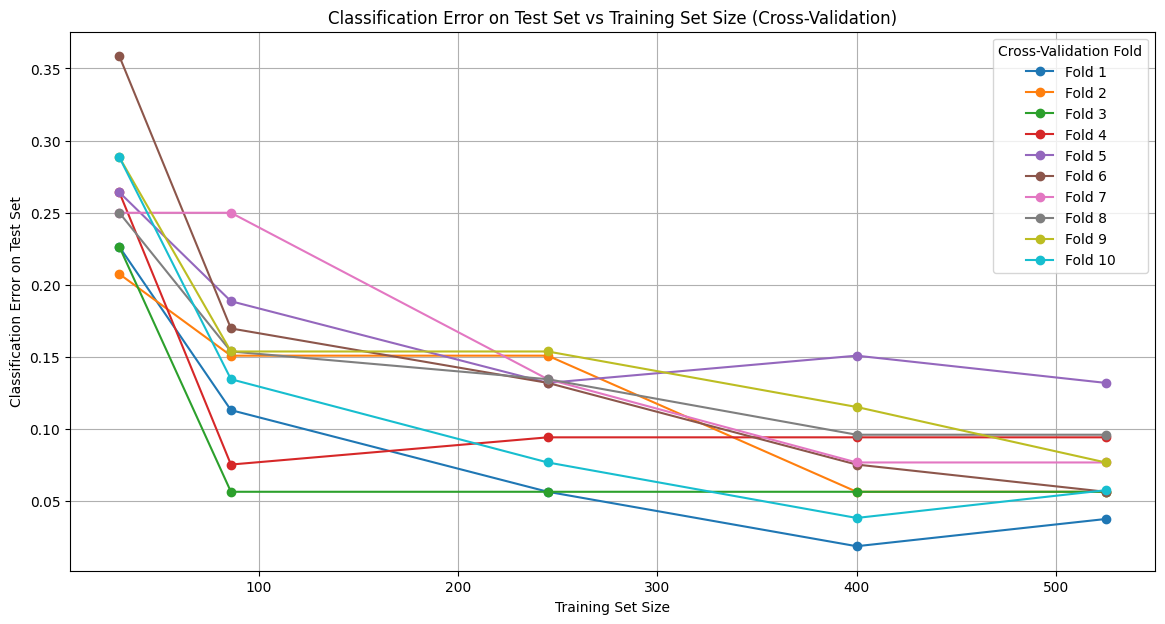

In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Setting up cross-validation strategy
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Collecting results for each fold
test_fold_results_cv = {f'Fold {i+1}': [] for i in range(cv.get_n_splits())}

# Using a loop to go through different training sizes
for train_size in train_sizes:
    for i, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        # Subsetting data for this fold
        X_train, X_test = X[train_idx][:train_size], X[test_idx]
        y_train, y_test = y[train_idx][:train_size], y[test_idx]
        
        # Training the model
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        clf.fit(X_train, y_train)

        # Calculating classification error
        test_error = 1 - clf.score(X_test, y_test)
        test_fold_results_cv[f'Fold {i+1}'].append((train_size, test_error))

# Plotting cross-validation results
plt.figure(figsize=(14, 7))
for fold, results in test_fold_results_cv.items():
    results_df = pd.DataFrame(results, columns=['train_size', 'test_error'])
    plt.plot(results_df['train_size'], results_df['test_error'], marker='o', linestyle='-', label=fold)

plt.title('Classification Error on Test Set vs Training Set Size (Cross-Validation)')
plt.xlabel('Training Set Size')
plt.ylabel('Classification Error on Test Set')
plt.legend(title='Cross-Validation Fold')
plt.grid(True)
plt.show()

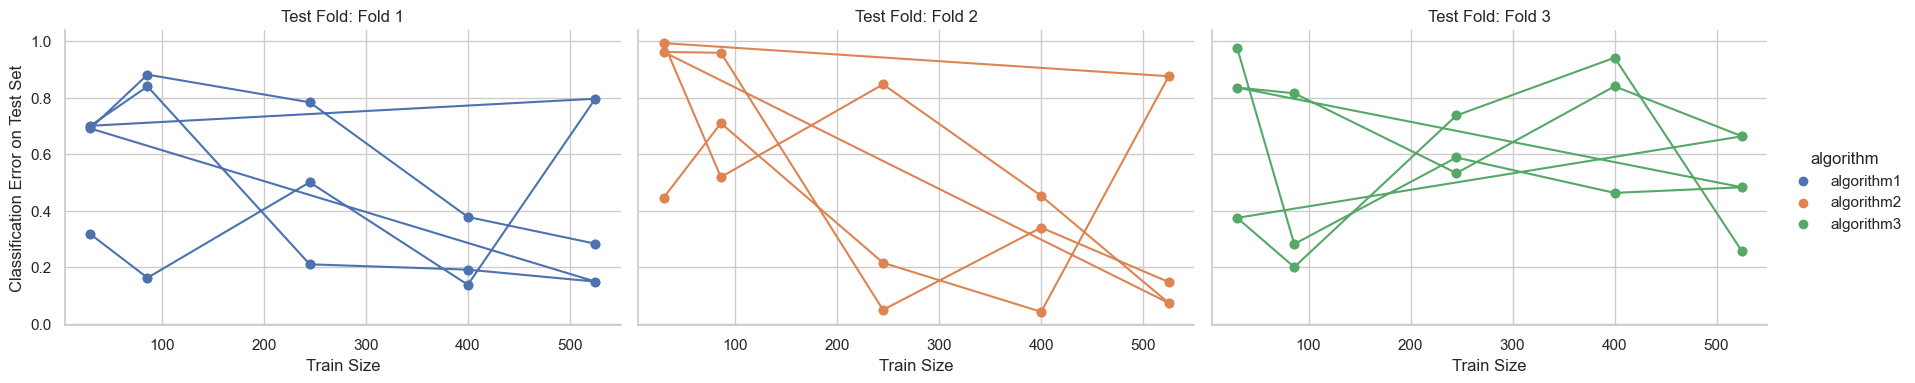

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Sample DataFrame structure, assuming the following columns:
# 'train_min_size', 'classification_error', 'algorithm', 'test_fold'
data = pd.DataFrame({
    'train_min_size': np.tile(train_sizes, 9),
    'classification_error': np.random.rand(45),  # Replace with actual error values
    'algorithm': np.repeat(['algorithm1', 'algorithm2', 'algorithm3'], 15),
    'test_fold': np.repeat(['Fold 1', 'Fold 2', 'Fold 3'], 15)
})

# Create the plot
sns.set(style="whitegrid")
g = sns.FacetGrid(data, col="test_fold", hue="algorithm", height=4, aspect=1.5)
g.map(plt.plot, "train_min_size", "classification_error", marker="o")
g.map(plt.scatter, "train_min_size", "classification_error")

# Add titles and labels
g.add_legend()
g.set_axis_labels("Train Size", "Classification Error on Test Set")
g.set_titles("Test Fold: {col_name}")

# Display the plot
plt.show()


In [13]:
from sklearn.ensemble import RandomForestClassifier
X_train, X_test, y_train, y_true = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize and train the classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [14]:
y_pred = clf.predict(X_test)


In [15]:
from sklearn.metrics import accuracy_score

# Calculate accuracy and classification error
accuracy = accuracy_score(y_true, y_pred)
classification_error = 1 - accuracy

print(f"Classification Error: {classification_error:.2f}")


Classification Error: 0.10


In [10]:
from sklearn.metrics import accuracy_score

# Assuming you have `y_true` (true labels) and `y_pred` (predicted labels)
accuracy = accuracy_score(y_true, y_pred)
classification_error = 1 - accuracy

print(f"Classification Error: {classification_error:.2f}")


NameError: name 'y_true' is not defined

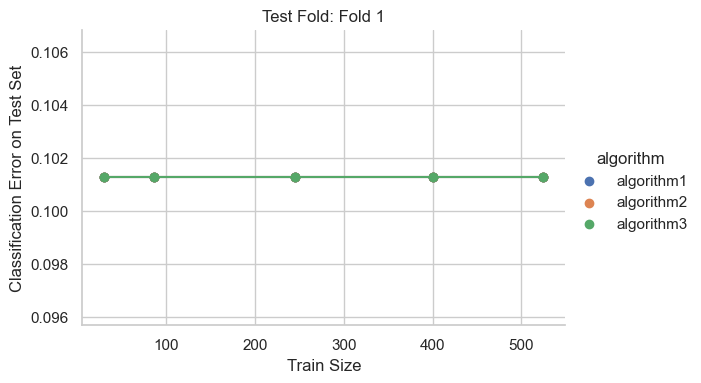

In [16]:
classification_errors = []

# Iterate over different training sizes and algorithms
for train_size in train_sizes:
    for algorithm in ['algorithm1', 'algorithm2', 'algorithm3']:
        # Assume `y_pred` is obtained from a trained model
        # Calculate classification error
        error = 1 - accuracy_score(y_true, y_pred)
        classification_errors.append({
            'train_min_size': train_size,
            'classification_error': error,
            'algorithm': algorithm,
            'test_fold': 'Fold 1'  # Replace with appropriate fold name
        })

# Create DataFrame for visualization
data = pd.DataFrame(classification_errors)

# Plot using seaborn
sns.set(style="whitegrid")
g = sns.FacetGrid(data, col="test_fold", hue="algorithm", height=4, aspect=1.5)
g.map(plt.plot, "train_min_size", "classification_error", marker="o")
g.map(plt.scatter, "train_min_size", "classification_error")
g.add_legend()
g.set_axis_labels("Train Size", "Classification Error on Test Set")
g.set_titles("Test Fold: {col_name}")
plt.show()


In [17]:
classification_errors = []

for train_size in train_sizes:
    for algorithm in ['Random Forest', 'Logistic Regression', 'SVC']:  # Replace with the actual algorithms you're using
        # Train and get predictions using the respective algorithm
        # Assume `y_pred` is obtained from a trained model for the specific `algorithm`
        
        # Calculate classification error
        error = 1 - accuracy_score(y_true, y_pred)
        
        # Append the result to the list
        classification_errors.append({
            'train_min_size': train_size,
            'classification_error': error,
            'algorithm': algorithm,
            'test_fold': 'Fold 1'  # Replace or vary for different folds if needed
        })

# Create DataFrame for visualization
data = pd.DataFrame(classification_errors)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVC': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

for algorithm_name, model in models.items():
    # Train and predict using the model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calculate classification error and store the result
    error = 1 - accuracy_score(y_true, y_pred)
    
    classification_errors.append({
        'train_min_size': train_size,
        'classification_error': error,
        'algorithm': algorithm_name,
        'test_fold': 'Fold 1'  # Modify as needed for each test fold
    })


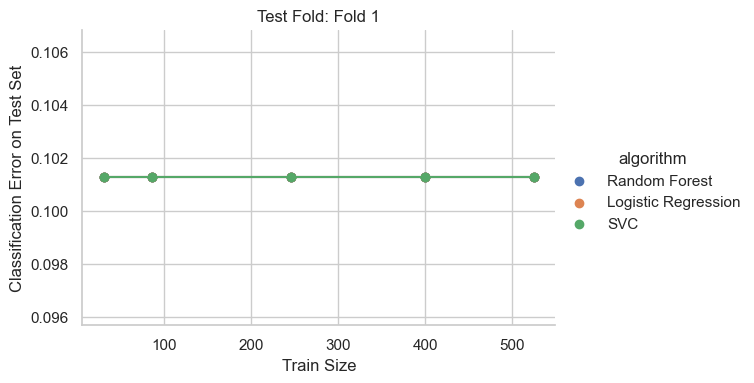

In [19]:
sns.set(style="whitegrid")
g = sns.FacetGrid(data, col="test_fold", hue="algorithm", height=4, aspect=1.5)
g.map(plt.plot, "train_min_size", "classification_error", marker="o")
g.map(plt.scatter, "train_min_size", "classification_error")
g.add_legend()
g.set_axis_labels("Train Size", "Classification Error on Test Set")
g.set_titles("Test Fold: {col_name}")
plt.show()


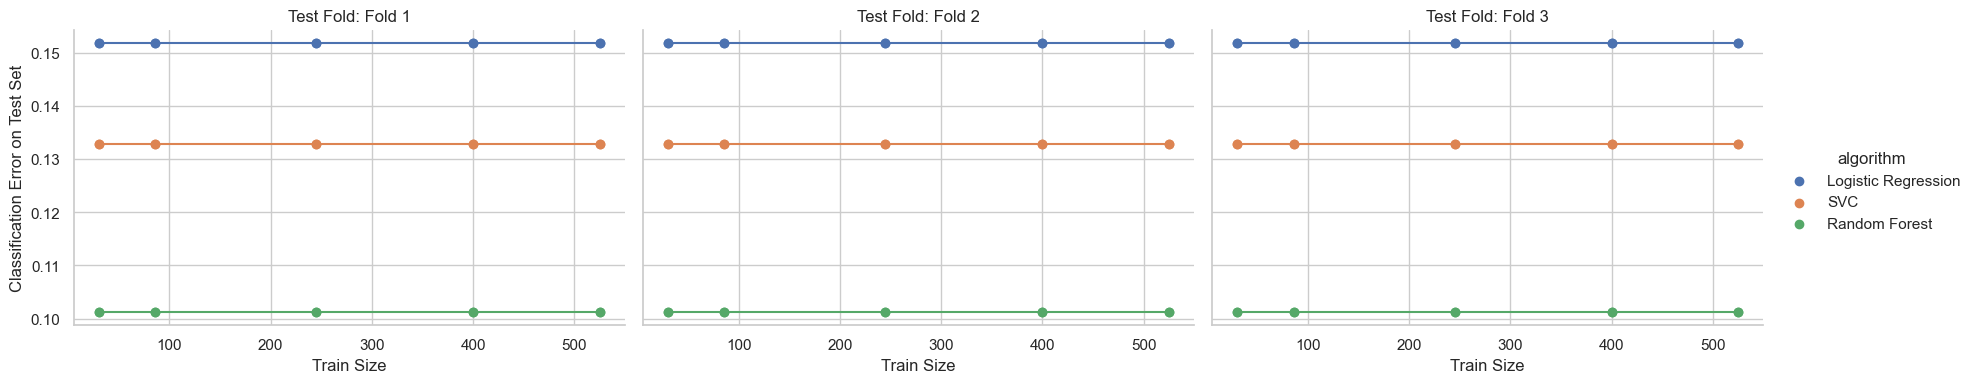

In [22]:
# List of algorithms to test
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVC': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Initialize a list to collect classification error data
classification_errors = []

# Simulate cross-validation folds (e.g., 3-fold CV)
folds = ['Fold 1', 'Fold 2', 'Fold 3']

# Generate data for each fold and algorithm
for fold in folds:
    for train_size in train_sizes:
        for algorithm_name, model in models.items():
            # Split the data (ensure reproducibility)
            X_train, X_test, y_train, y_true = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
            
            # Train the model
            model.fit(X_train, y_train)
            
            # Get predictions
            y_pred = model.predict(X_test)
            
            # Calculate classification error
            error = 1 - accuracy_score(y_true, y_pred)
            
            # Append the result
            classification_errors.append({
                'train_min_size': train_size,
                'classification_error': error,
                'algorithm': algorithm_name,
                'test_fold': fold
            })

# Create the DataFrame for visualization
data = pd.DataFrame(classification_errors)

# Plot using seaborn
sns.set(style="whitegrid")
g = sns.FacetGrid(data, col="test_fold", hue="algorithm", height=4, aspect=1.5)
g.map(plt.plot, "train_min_size", "classification_error", marker="o")
g.map(plt.scatter, "train_min_size", "classification_error")
g.add_legend()
g.set_axis_labels("Train Size", "Classification Error on Test Set")
g.set_titles("Test Fold: {col_name}")
plt.show()


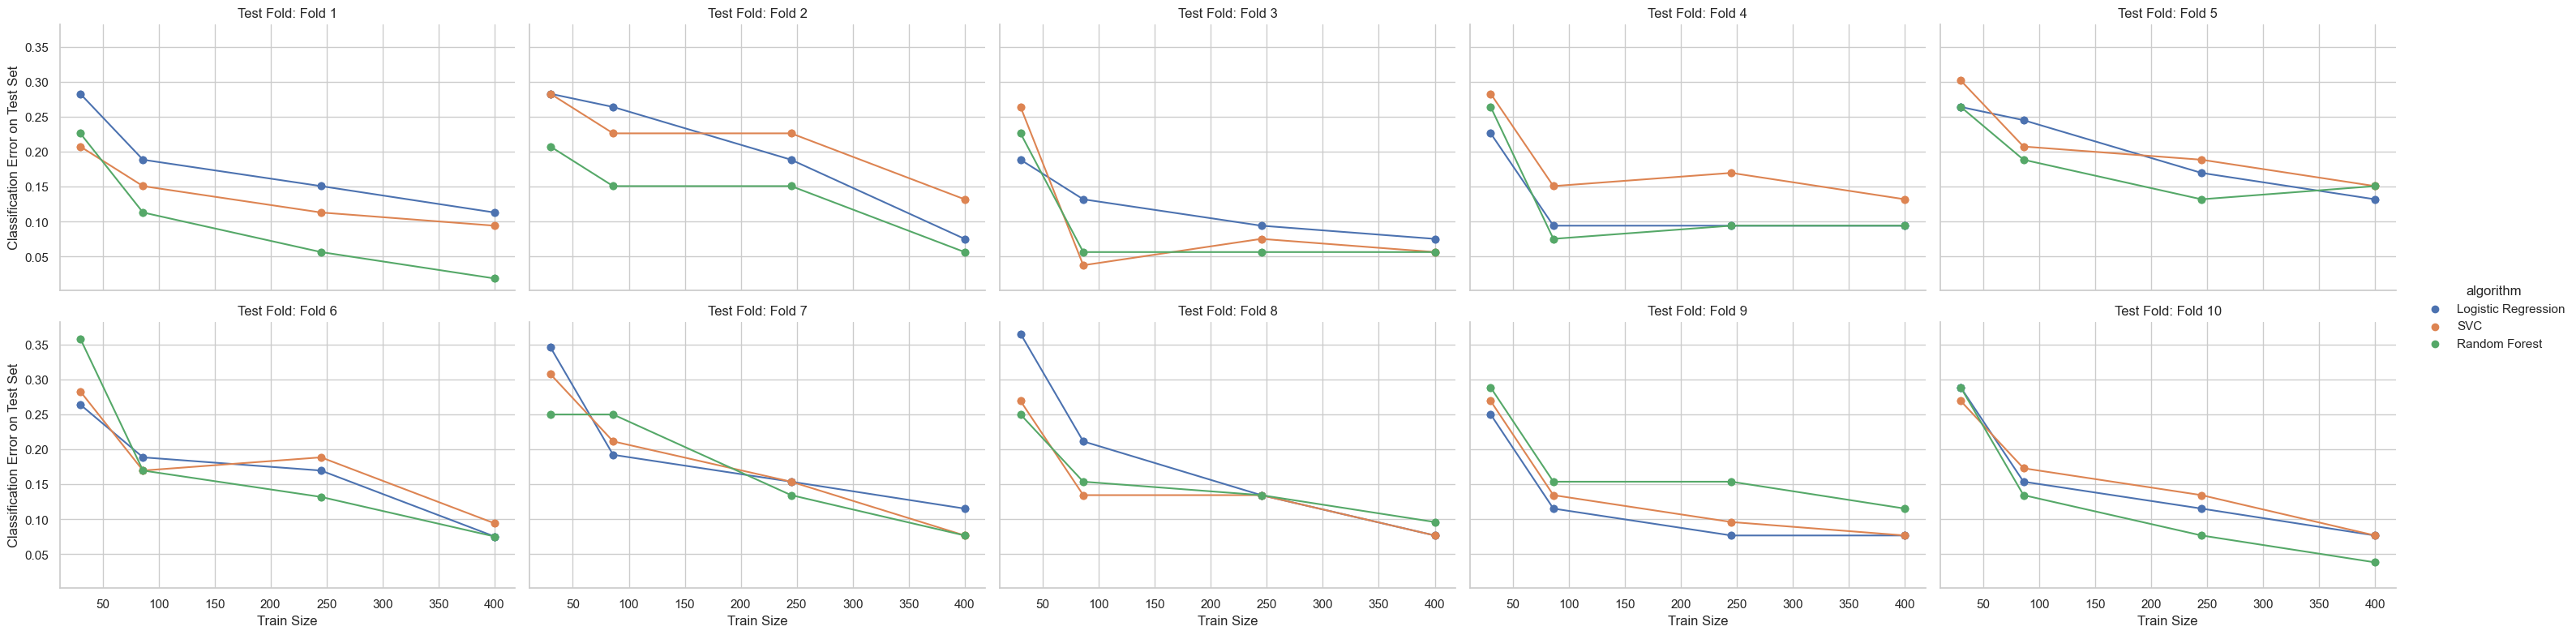

In [29]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVC': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

classification_errors = []

# Setting up 10-fold cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Generate data for each fold, algorithm, and training size
for train_size in train_sizes:
    for algorithm_name, model in models.items():
        fold_number = 1  # To label folds in the DataFrame

        for train_idx, test_idx in kf.split(X, y):
            # Ensure the training size is not larger than the current training fold size
            if train_size < len(train_idx):
                X_train = X[train_idx][:train_size]
                y_train = y[train_idx][:train_size]
                X_test = X[test_idx]
                y_true = y[test_idx]

                # Train the model
                model.fit(X_train, y_train)

                # Get predictions and calculate classification error
                y_pred = model.predict(X_test)
                error = 1 - accuracy_score(y_true, y_pred)

                # Append the result
                classification_errors.append({
                    'train_min_size': train_size,
                    'classification_error': error,
                    'algorithm': algorithm_name,
                    'test_fold': f'Fold {fold_number}'
                })

            fold_number += 1

# Create the DataFrame for visualization
data = pd.DataFrame(classification_errors)

# Plot using seaborn
sns.set(style="whitegrid")
g = sns.FacetGrid(data, col="test_fold", hue="algorithm", height=4, aspect=1.5, col_wrap=5)
g.map(plt.plot, "train_min_size", "classification_error", marker="o")
g.map(plt.scatter, "train_min_size", "classification_error")
g.add_legend()
g.set_axis_labels("Train Size", "Classification Error on Test Set")
g.set_titles("Test Fold: {col_name}")
plt.show()


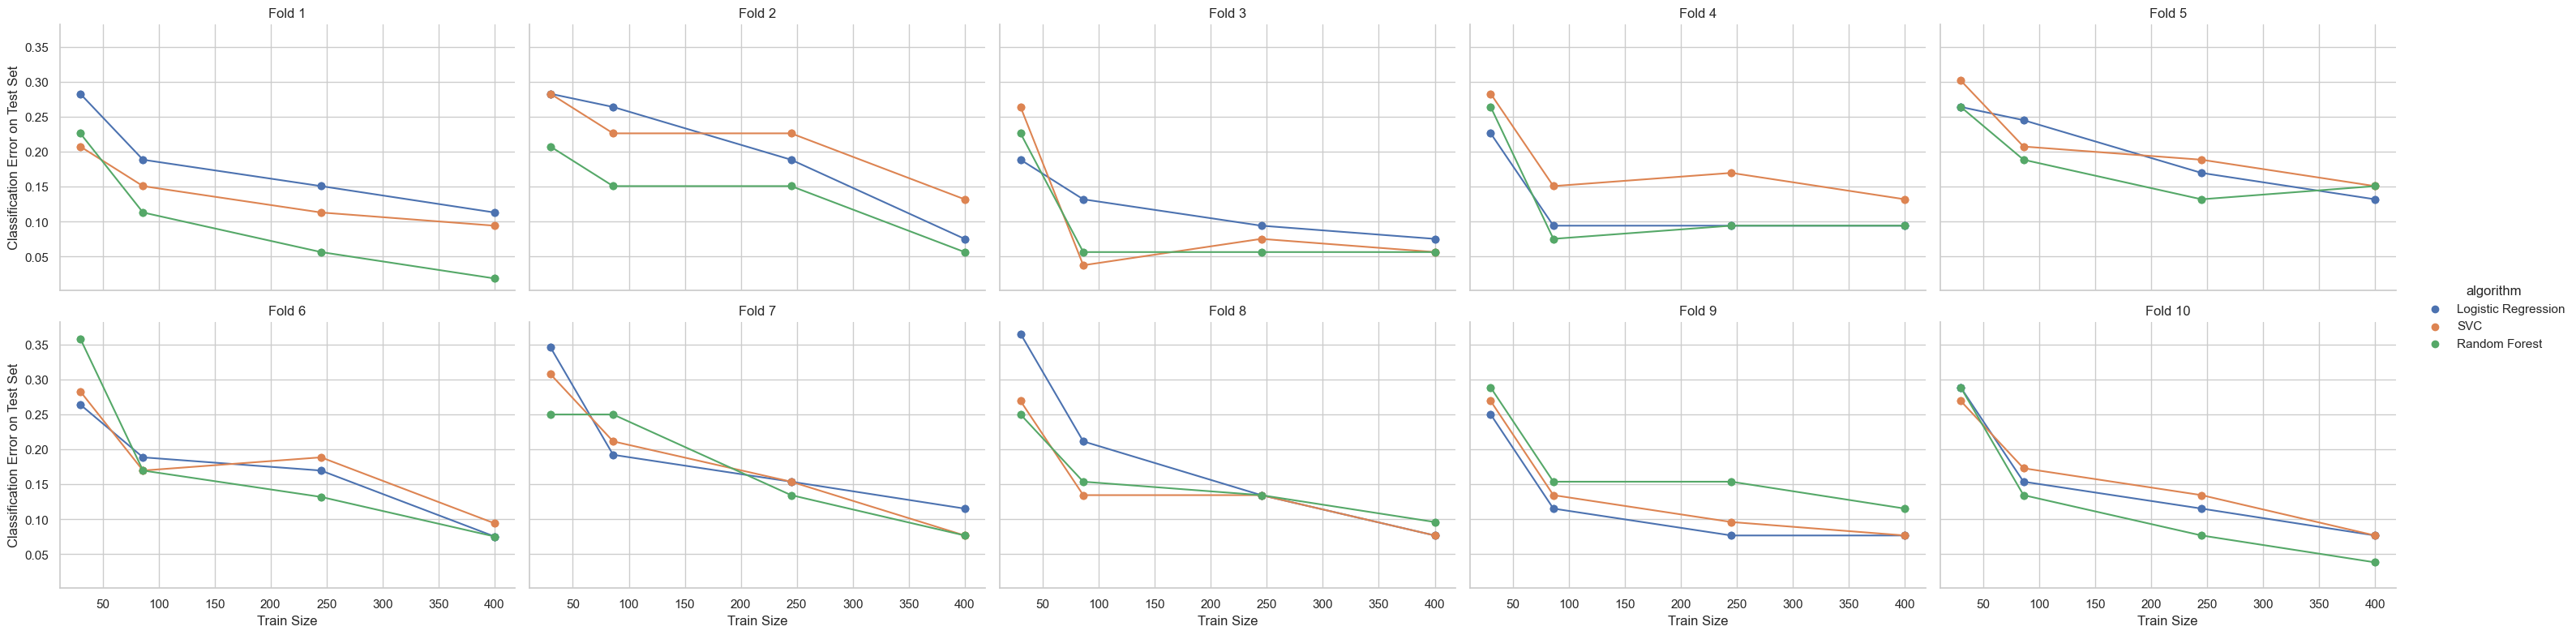

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packa

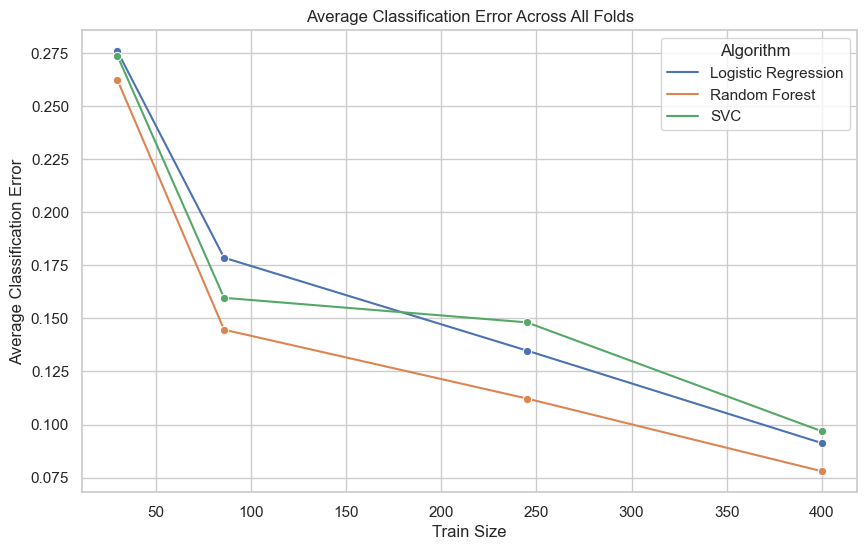

In [30]:

# Calculate average classification error for each train size and algorithm
average_errors = data.groupby(['train_min_size', 'algorithm'])['classification_error'].mean().reset_index()

# Plot using seaborn with 2 rows and 5 columns for individual folds
sns.set(style="whitegrid")
g = sns.FacetGrid(data, col="test_fold", hue="algorithm", height=4, aspect=1.5, col_wrap=5)
g.map(plt.plot, "train_min_size", "classification_error", marker="o")
g.map(plt.scatter, "train_min_size", "classification_error")
g.add_legend()
g.set_axis_labels("Train Size", "Classification Error on Test Set")
g.set_titles("{col_name}")
plt.show()

# Plot the average classification error across all folds
plt.figure(figsize=(10, 6))
sns.lineplot(data=average_errors, x='train_min_size', y='classification_error', hue='algorithm', marker='o')
plt.title('Average Classification Error Across All Folds')
plt.xlabel('Train Size')
plt.ylabel('Average Classification Error')
plt.grid(True)
plt.legend(title='Algorithm')
plt.show()

In [27]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Initialize a range of random seeds
seeds = [42, 100, 123, 456, 789]  # Example of different seeds

# Collect classification error data with different seeds
classification_errors = []

for seed in seeds:
    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)
    
    for train_size in train_sizes:
        for algorithm_name, model in models.items():
            fold_number = 1  # To label folds in the DataFrame

            for train_idx, test_idx in kf.split(X, y):
                if train_size < len(train_idx):
                    X_train = X[train_idx][:train_size]
                    y_train = y[train_idx][:train_size]
                    X_test = X[test_idx]
                    y_true = y[test_idx]

                    # Train the model
                    model.fit(X_train, y_train)

                    # Get predictions and calculate classification error
                    y_pred = model.predict(X_test)
                    error = 1 - accuracy_score(y_true, y_pred)

                    # Append the result with seed as an identifier
                    classification_errors.append({
                        'train_min_size': train_size,
                        'classification_error': error,
                        'algorithm': algorithm_name,
                        'test_fold': f'Fold {fold_number}',
                        'seed': seed
                    })

                fold_number += 1

# Create a DataFrame for visualization
data = pd.DataFrame(classification_errors)


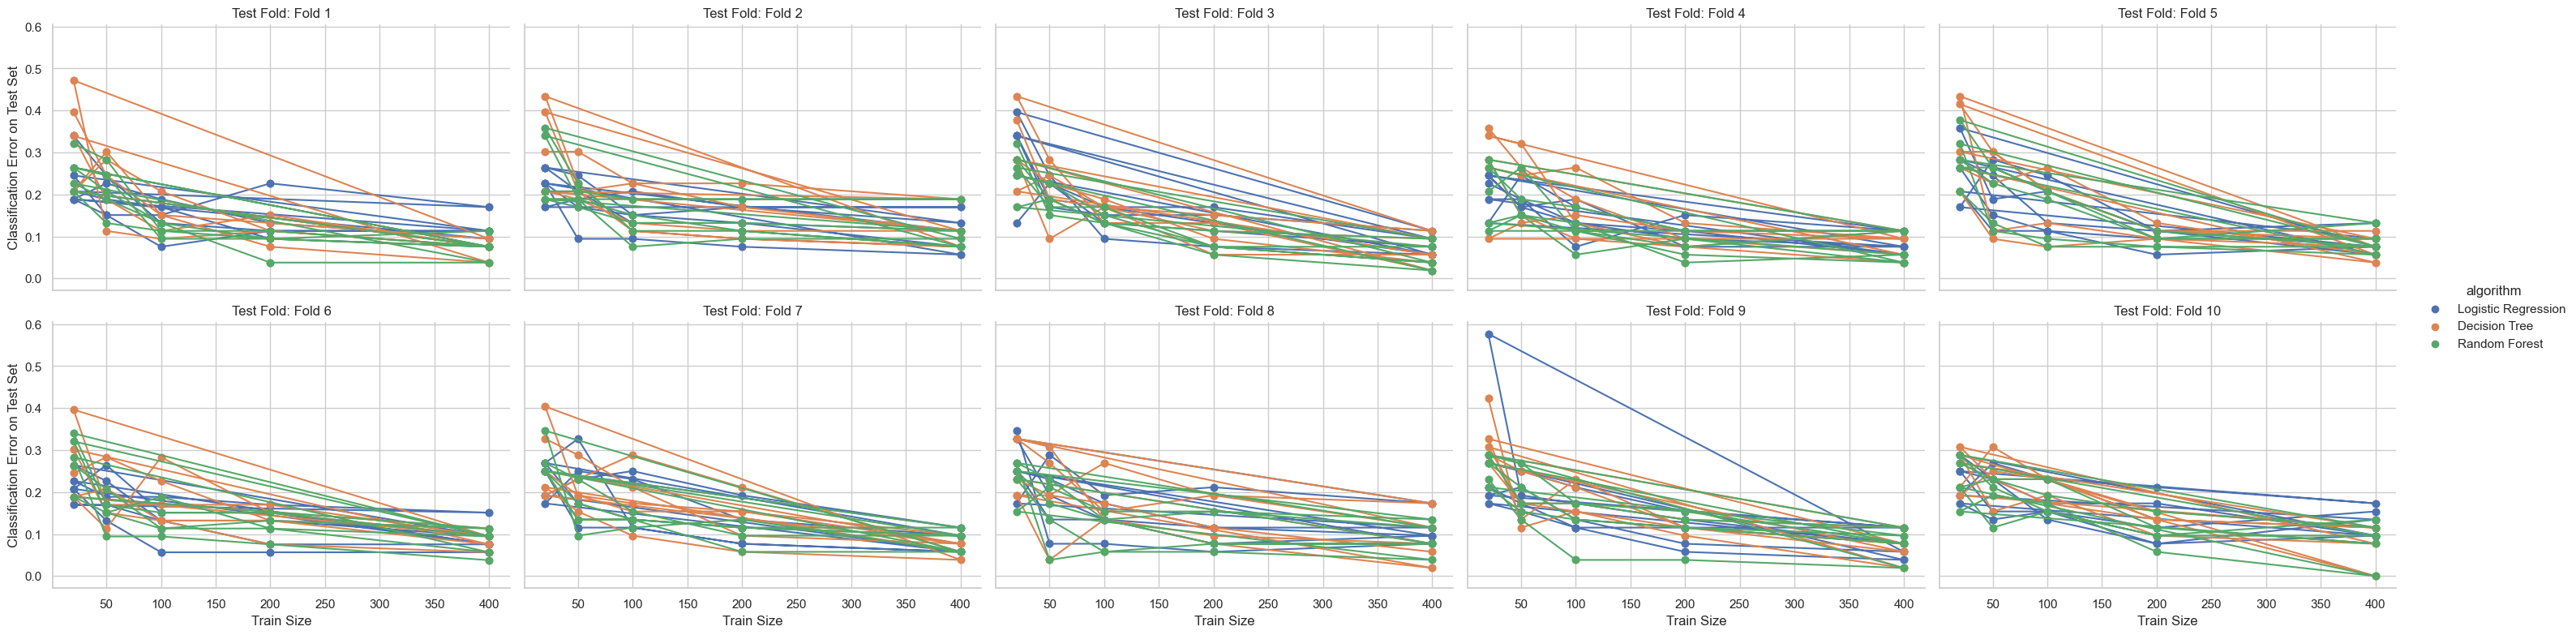

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packa

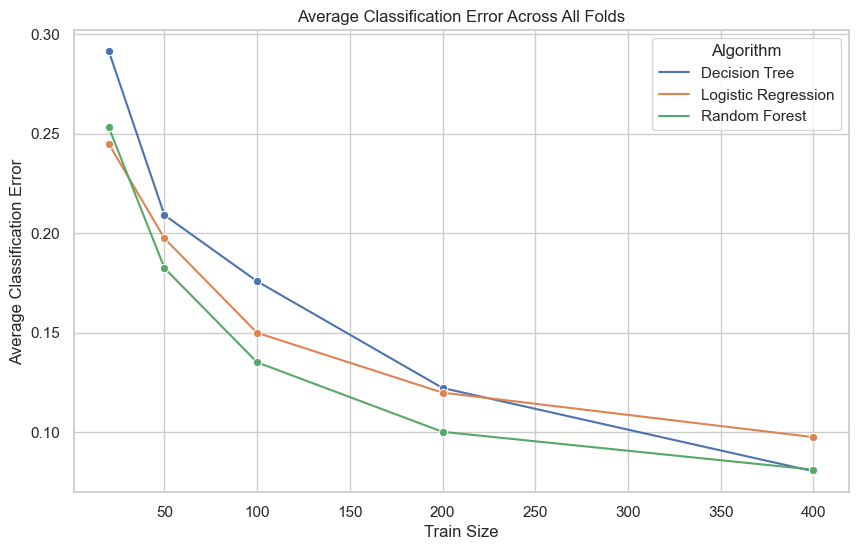

In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Generate a synthetic dataset for demonstration
np.random.seed(42)

# List of training sizes and random seeds
train_sizes = [20, 50, 100, 200, 400, 525]
random_seeds = [42, 100, 123, 456, 789]  # Different random seeds for variability

# Algorithms to test
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Collect classification error data with different training sizes, algorithms, and seeds
classification_errors = []

# Using 10-fold cross-validation for each random seed
kf = StratifiedKFold(n_splits=10, shuffle=True)

for seed in random_seeds:
    for train_size in train_sizes:
        for algorithm_name, model in models.items():
            fold_number = 1  # To label folds in the DataFrame

            for train_idx, test_idx in kf.split(X, y):
                # Shuffle data based on the seed for each fold
                np.random.seed(seed)
                np.random.shuffle(train_idx)
                
                if train_size < len(train_idx):
                    X_train = X[train_idx][:train_size]
                    y_train = y[train_idx][:train_size]
                    X_test = X[test_idx]
                    y_true = y[test_idx]

                    # Train the model
                    model.fit(X_train, y_train)

                    # Get predictions and calculate classification error
                    y_pred = model.predict(X_test)
                    error = 1 - accuracy_score(y_true, y_pred)

                    # Append the result with seed and fold as identifiers
                    classification_errors.append({
                        'train_min_size': train_size,
                        'classification_error': error,
                        'algorithm': algorithm_name,
                        'test_fold': f'Fold {fold_number}',
                        'seed': seed
                    })

                fold_number += 1

# Create a DataFrame for visualization
data = pd.DataFrame(classification_errors)

# Plot using seaborn with 2 rows and 5 columns for individual folds
sns.set(style="whitegrid")
g = sns.FacetGrid(data, col="test_fold", hue="algorithm", height=4, aspect=1.5, col_wrap=5)
g.map(plt.plot, "train_min_size", "classification_error", marker="o")
g.map(plt.scatter, "train_min_size", "classification_error")
g.add_legend()
g.set_axis_labels("Train Size", "Classification Error on Test Set")
g.set_titles("Test Fold: {col_name}")
plt.show()

# Calculate and plot the average classification error across all folds for each algorithm and training size
average_errors = data.groupby(['train_min_size', 'algorithm'])['classification_error'].mean().reset_index()

# Plot the average classification error
plt.figure(figsize=(10, 6))
sns.lineplot(data=average_errors, x='train_min_size', y='classification_error', hue='algorithm', marker='o')
plt.title('Average Classification Error Across All Folds')
plt.xlabel('Train Size')
plt.ylabel('Average Classification Error')
plt.grid(True)
plt.legend(title='Algorithm')
plt.show()
